In [1]:
import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

label = 'pident_90'
os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()
title_ifont = FontProperties(fname=ifont_path, size=8)

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
def get_link_data(genus_name):
    set1 = plt.cm.Set1.colors
    
    mobility_map = {
        'non-mobilizable': set1[0],
        'mobilizable': set1[2],
        'conjugative': set1[1]
    }
    
    amr_map = {
        'AMR': set1[-2],
        'non-AMR': set1[-1]
    }

    base_folder = '/active-data/analysis_results/chr_pla/genus'
    replicon_data = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    dot_sample = pd.read_csv(f'{base_folder}/figure_data/circle_layer_network_output/{genus_name}/all_dot_table.csv')
    line_sample = pd.read_csv(f'{base_folder}/figure_data/circle_layer_network_output/{genus_name}/all_link_table.csv')
    
    mob_type = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/annotations/NMS_replicon_mobtyper_results.tsv', sep='\t', index_col=0)
    mob_type = mob_type.rename(columns={'id': 'acc'})
    amr_type = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/annotations/NMS_replicon_AMRtyper_results.tsv', sep='\t', index_col=0)
    amr_type = amr_type.drop_duplicates(subset=['accession'], keep='first')
    amr_type = amr_type.rename(columns={'accession': 'acc'})
    
    dot_merged = pd.merge(dot_sample, mob_type[['acc', 'predicted_mobility']], on='acc', how='left')
    dot_merged = pd.merge(dot_merged, amr_type, on='acc', how='left')
    dot_merged['color_mobility'] = dot_merged['predicted_mobility'].map(mobility_map)
    dot_merged['color_amr'] = dot_merged['AMR_type'].map(amr_map)
    dot_merged['layer_new'] = np.ceil(dot_merged['layer']) - 1
    dot_merged['layer_new'] = dot_merged['layer_new'].astype(int)
    dot_merged = pd.merge(dot_merged, replicon_data[['accession', 'size', 'average plasmid fraction-pident_90']].rename(columns={'accession': 'acc', 'average plasmid fraction-pident_90': 'plasmidness'}), on='acc', how='left')
    dot_merged['log10_size'] = np.log10(dot_merged['size'])
    
    plasmidness_cmap = LinearSegmentedColormap.from_list(
        "plasmidness_blue_yellow", ["#ff7f0e", '#a5d6a5', "#cce7ff"]
    )
    dot_merged['color_plasmidness'] = dot_merged['plasmidness'].apply(
        lambda x: to_hex(plasmidness_cmap(x))
    )

    return dot_merged

In [3]:
def plot_stacked_percentage(ax, df, category_col, color_col):
    counts = df.groupby(['layer_new', category_col]).size().unstack(fill_value=0)
    percent = counts.div(counts.sum(axis=1), axis=0) * 100

    color_dict = {}
    for cat in df[category_col].unique():
        color = df[df[category_col] == cat][color_col].iloc[0]
        if isinstance(color, str):
            color = eval(color)
        color_dict[cat] = color
    cats = percent.columns.tolist()
    plot_colors = [color_dict[col] for col in percent.columns]

    x = np.arange(len(percent.index))
    width = 0.9
    bottom = np.zeros(len(percent.index))

    for i, cat in enumerate(cats):
        if len(cat) > 0 and not cat[0].isupper():
            cat_label = cat[0].upper() + cat[1:]
        else:
            cat_label = cat
        ax.bar(
            x, percent[cat], width, bottom=bottom,
            label=cat_label, color=plot_colors[i], alpha=0.8,
        )
        for j, (p, raw_val) in enumerate(zip(percent[cat], counts[cat])):
            if p > 0:
                ax.text(
                    x[j], bottom[j] + p/2,
                    str(int(raw_val)),
                    ha='center', va='center', fontsize=7, color='black'
                )
        bottom += percent[cat]

    ax.set_xticks(x)
    ax.set_xticklabels(percent.index, rotation=0)
    ax.set_xlim(-0.5, len(x)-0.5)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('Layer')
    ax.set_ylim(0, 100)
    title_label = category_col.replace('_', ' ')
    if not title_label[0].isupper():
        title_label = title_label.capitalize()
    # ax.legend(title=title_label, bbox_to_anchor=(1.05, 1), loc='upper left')

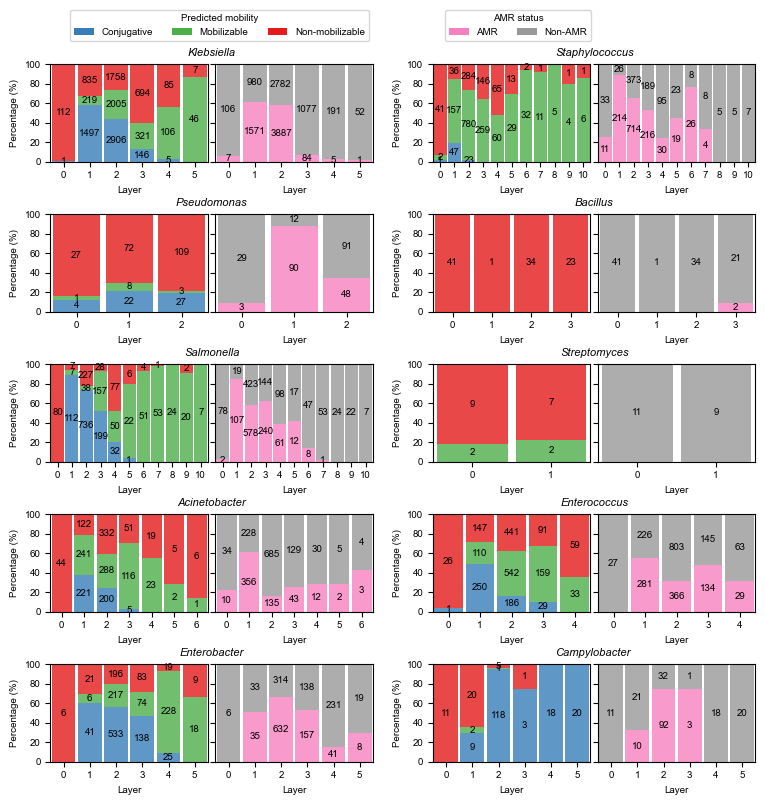

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, to_hex
from matplotlib.patches import Patch

fig = plt.figure(figsize=(7.5, 7.5))
i = 0
for genus_name in keep_genus:
    if genus_name == 'Escherichia':
        continue
    try:
        dot_merged = get_link_data(genus_name)
        if len(dot_merged['layer_new'].value_counts()) <= 1:
            continue
    except:
        continue
    y_bottom = 1 - 0.2*int(i/2) - 0.165
    ax_main = fig.add_axes([0+0.06+0.51*(i%2),y_bottom,0.43,0.13])
    ax_main.set_title(genus_name, fontproperties=title_ifont)
    ax_main.axis('off')
    ax_mob_sta = fig.add_axes([0+0.06+0.51*(i%2),y_bottom,0.21,0.13])
    plot_stacked_percentage(ax_mob_sta, dot_merged, category_col='predicted_mobility', color_col='color_mobility')
    ax_amr_sta = fig.add_axes([0.25+0.03+0.51*(i%2),y_bottom,0.21,0.13])
    plot_stacked_percentage(ax_amr_sta, dot_merged, category_col='AMR_type', color_col='color_amr')
    ax_amr_sta.set_ylabel('')
    ax_amr_sta.set_yticklabels([])
    i += 1

set1 = plt.cm.Set1.colors
mob_elements = [Patch(facecolor=set1[1],label='Conjugative'), 
                Patch(facecolor=set1[2],label='Mobilizable'), 
                Patch(facecolor=set1[0],label='Non-mobilizable')]
fig.legend(handles=mob_elements, loc='lower left',bbox_to_anchor=(0.08,0.99),fontsize=7,title='Predicted mobility',ncol=3)

amr_elements = [Patch(facecolor=set1[-2],label='AMR'), 
                Patch(facecolor=set1[-1],label='Non-AMR')]
fig.legend(handles=amr_elements, loc='lower left',bbox_to_anchor=(0.58,0.99),fontsize=7,title='AMR status',ncol=2)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
# fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_layer_statistics.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_layer_statistics.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()